CustomerID                0
Gender                    1
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1     NaN   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
   CustomerID Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    NaN   19                  15                      39
CustomerID                   1
Gender                    Male
Age                         19
Annual Income (k$)          15
Spending Score (1-100)      39
Name: 0, dtype: object
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19      

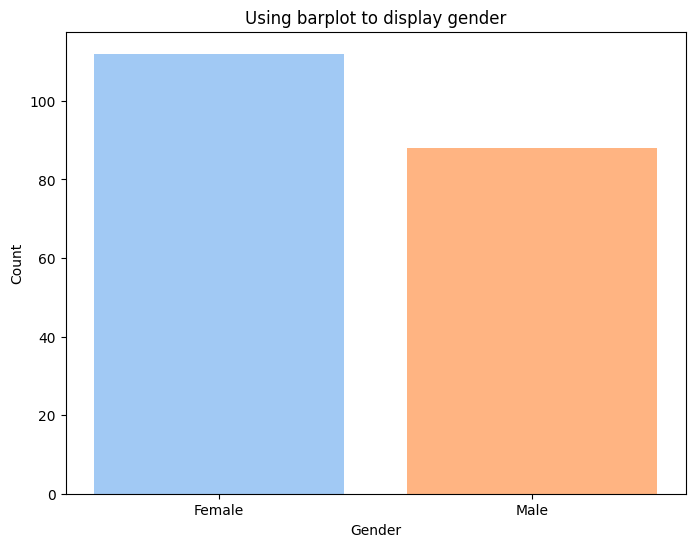

count    200.000000
mean      38.850000
std       13.969007
min       18.000000
25%       28.750000
50%       36.000000
75%       49.000000
max       70.000000
Name: Age, dtype: float64


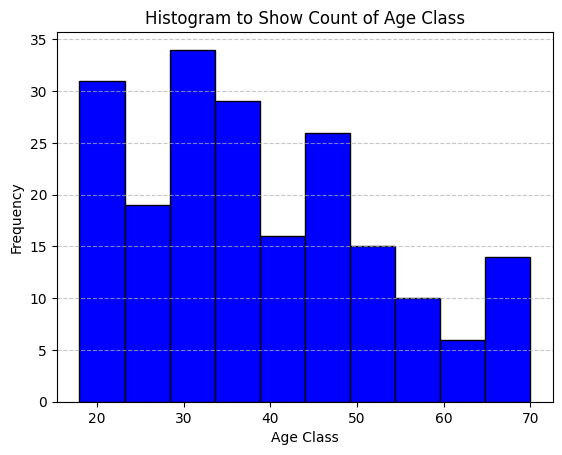

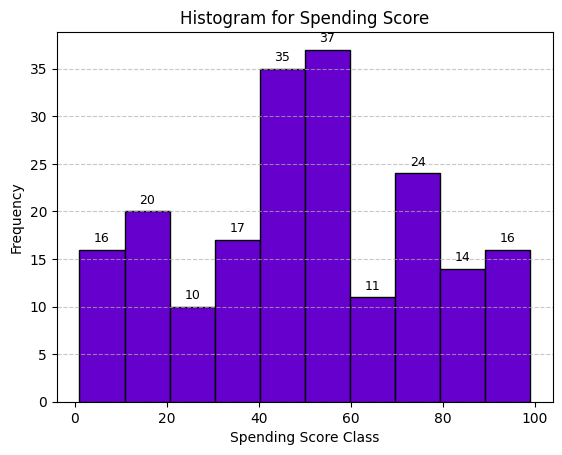

count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income (k$), dtype: float64


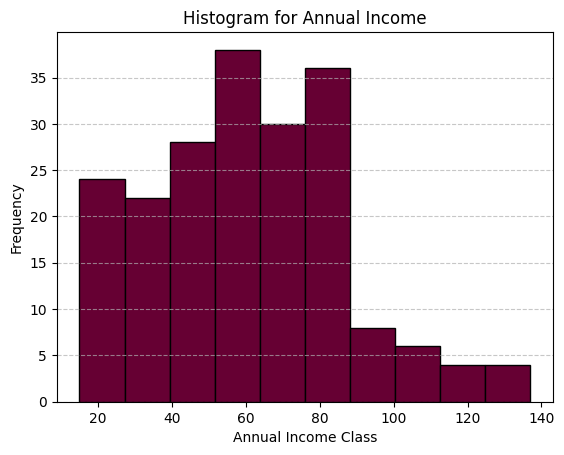

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
MinMaxScaler()


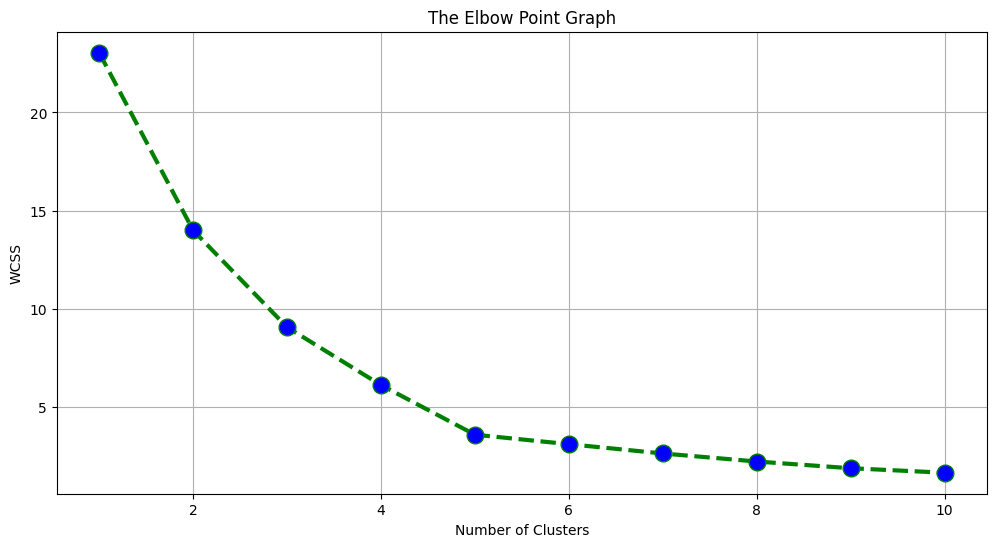

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]
[[0.33029751 0.49508692]
 [0.58638083 0.82783883]
 [0.6        0.16443149]
 [0.09265859 0.20319432]
 [0.08792846 0.79962894]]


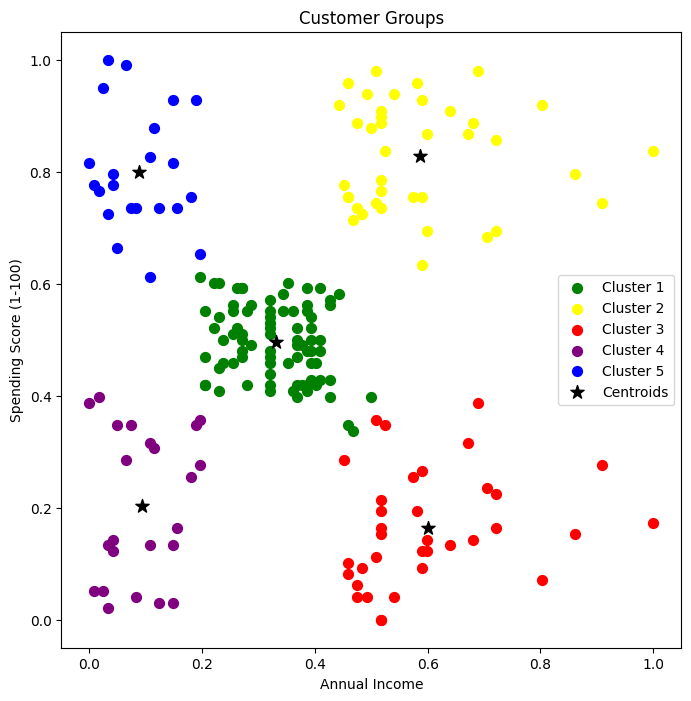

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Load dataset
customer_data = pd.read_csv("Mall_Customers.csv")
print(customer_data.isnull().sum())
print(customer_data.head())
print(customer_data[customer_data['Gender'].isnull()])
customer_data.at[0, 'Gender'] = 'Male'
print(customer_data.loc[0])
print(customer_data.head())
print(customer_data.info())
print(customer_data.columns)

# Gender bar plot
gender_counts = customer_data['Gender'].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(gender_counts.index, gender_counts.values, color=sns.color_palette('pastel'))
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Using barplot to display gender")
plt.xticks(gender_counts.index)
plt.show()

# Gender pie chart (optional, not plotted in original code)
a = [60, 40]  # Replace with actual counts if needed
labels = ['Female', 'Male']
total = sum(a)
pct = [round(x / total * 100) for x in a]
label_text = [f"{label} {p}%" for label, p in zip(labels, pct)]

# Summary statistics for Age
print(customer_data['Age'].describe())

# Histogram of Age
plt.hist(customer_data['Age'], color='blue', edgecolor='black')
plt.title('Histogram to Show Count of Age Class')
plt.xlabel('Age Class')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Histogram for Spending Score
counts, bins, patches = plt.hist(customer_data['Spending Score (1-100)'], color="#6600cc", edgecolor='black')
plt.title("Histogram for Spending Score")
plt.xlabel("Spending Score Class")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
for count, patch in zip(counts, patches):
    plt.text(patch.get_x() + patch.get_width() / 2, count + 0.5, int(count), ha='center', va='bottom', fontsize=9)
plt.show()

# Summary statistics for Annual Income
print(customer_data['Annual Income (k$)'].describe())

# Histogram for Annual Income
plt.hist(customer_data['Annual Income (k$)'], color="#660033", edgecolor='black')
plt.title("Histogram for Annual Income")
plt.xlabel("Annual Income Class")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Clustering using KMeans
print(customer_data.columns)
X = customer_data.loc[:, ['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = MinMaxScaler().fit(X)
print(scaler)
scaler.feature_range
X = scaler.transform(X)

# Elbow method to find optimal clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.grid()
plt.plot(range(1, 11), wcss, color='green', linestyle='dashed', linewidth=3,
         marker='o', markerfacecolor='blue', markersize=12)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Apply KMeans with 5 clusters
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10)
label = kmeans.fit_predict(X)
print(label)
print(kmeans.cluster_centers_)

# Plot clusters
plt.figure(figsize=(8, 8))
plt.scatter(X[label == 0, 0], X[label == 0, 1], s=50, c='green', label='Cluster 1')
plt.scatter(X[label == 1, 0], X[label == 1, 1], s=50, c='yellow', label='Cluster 2')
plt.scatter(X[label == 2, 0], X[label == 2, 1], s=50, c='red', label='Cluster 3')
plt.scatter(X[label == 3, 0], X[label == 3, 1], s=50, c='purple', label='Cluster 4')
plt.scatter(X[label == 4, 0], X[label == 4, 1], s=50, c='blue', label='Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=100, c='black', marker='*', label='Centroids')
plt.title('Customer Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()